# Task 1/2: EDA — Brent Oil Prices

Loading raw data, checking trend/stationarity/volatility, and computing log returns
ahead of Bayesian change point modeling.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [14]:
df = pd.read_csv('../data/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [15]:
print(df.shape)
print(df['Date'].min(), 'to', df['Date'].max())
df.describe()

(9011, 2)
1987-05-20 00:00:00 to 2022-11-14 00:00:00


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


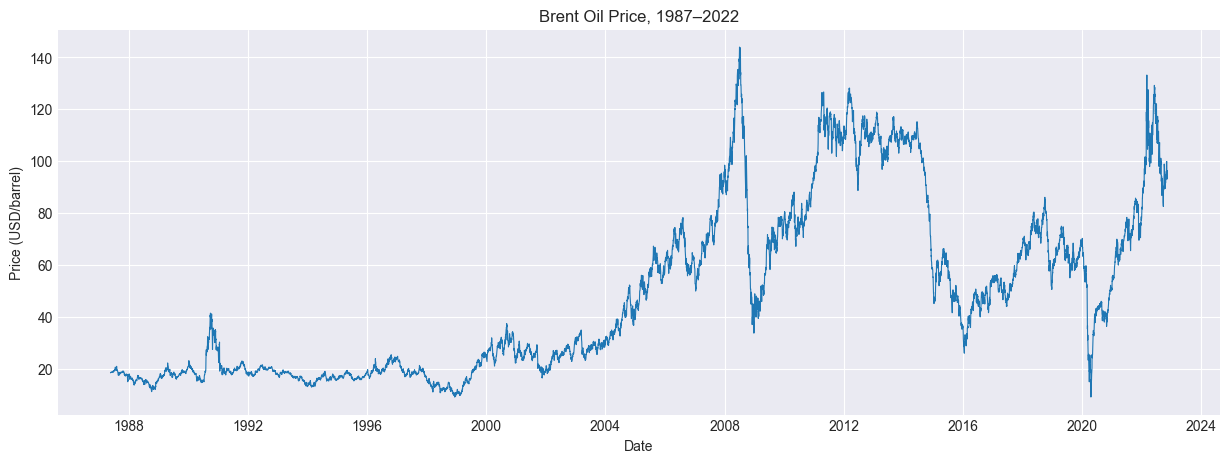

In [16]:
plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['Price'], linewidth=0.8)
plt.title('Brent Oil Price, 1987–2022')
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.savefig('01_raw_price.png', dpi=150, bbox_inches='tight')
plt.show()

## Trend and stationarity

The raw price series clearly shows long-term trends and multiple regime shifts
(1990, 2008, 2014-16, 2020). Let's test formally for stationarity.

In [17]:
result = adfuller(df['Price'].dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'Non-stationary')

ADF Statistic: -1.9939
p-value: 0.2893
Non-stationary


In [18]:
df['log_price'] = np.log(df['Price'])
df['log_return'] = df['log_price'].diff()
df = df.dropna().reset_index(drop=True)
df.head()

,Date,Price,log_price,log_return
0,1987-05-21,18.45,2.915064,-0.009709
1,1987-05-22,18.55,2.920470,0.005405
2,1987-05-25,18.60,2.923162,0.002692
3,1987-05-26,18.63,2.924773,0.001612
4,1987-05-27,18.60,2.923162,-0.001612


In [19]:
result_lr = adfuller(df['log_return'])
print(f'ADF Statistic: {result_lr[0]:.4f}')
print(f'p-value: {result_lr[1]:.4f}')
print('Stationary' if result_lr[1] < 0.05 else 'Non-stationary')

ADF Statistic: -16.4271
p-value: 0.0000
Stationary


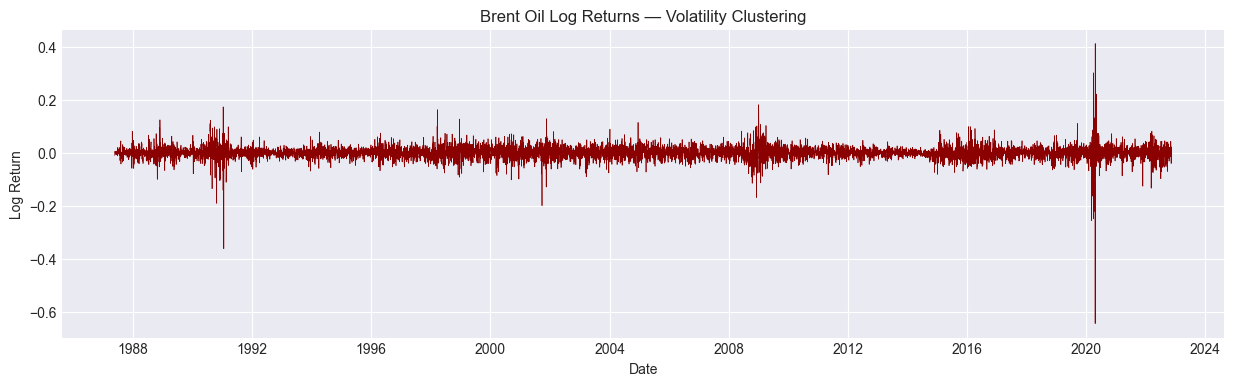

In [20]:
plt.figure(figsize=(15,4))
plt.plot(df['Date'], df['log_return'], linewidth=0.5, color='darkred')
plt.title('Brent Oil Log Returns — Volatility Clustering')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.savefig('02_log_returns.png', dpi=150, bbox_inches='tight')
plt.show()

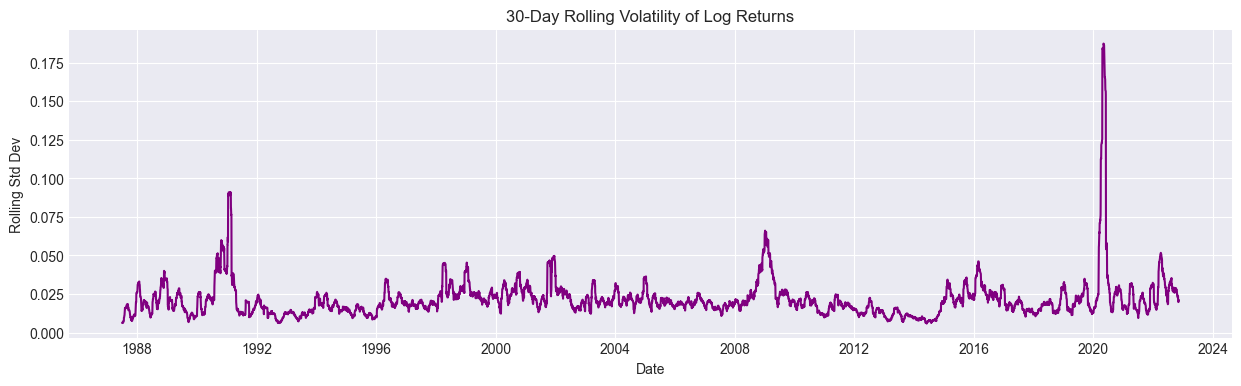

In [21]:
df['rolling_vol_30d'] = df['log_return'].rolling(30).std()

plt.figure(figsize=(15,4))
plt.plot(df['Date'], df['rolling_vol_30d'], color='purple')
plt.title('30-Day Rolling Volatility of Log Returns')
plt.xlabel('Date')
plt.ylabel('Rolling Std Dev')
plt.savefig('03_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of findings

- **Trend:** Raw price is non-stationary (ADF fails to reject unit root), with
  multiple visible structural regimes.
- **Stationarity:** Log returns are stationary (ADF rejects unit root at 5%),
  making them the right series to model rather than raw price.
- **Volatility:** Clear volatility clustering visible around 2008, 2014-2016,
  and 2020 — consistent with major known shocks. This motivates using a
  change point model on log returns rather than a simple linear trend model.

Next: Bayesian change point model in `02_changepoint_model.ipynb`.

In [22]:
df.to_csv('../data/processed_returns.csv', index=False)
print('Saved processed_returns.csv')

Saved processed_returns.csv
